# Evaluación del modelo: análisis en profundidad

En este notebook se analiza en detalle el mejor modelo seleccionado en `03_models.ipynb` (LightGBM optimizado). El objetivo es evaluar su comportamiento desde distintos ángulos antes de sacar conclusiones:

- **Curvas ROC y Precision-Recall**: capacidad discriminativa
- **Importancia de variables**: qué factores pesan más en la predicción
- **Análisis de umbral**: cómo afecta el umbral al trade-off precision/recall
- **Calibración y Brier Score**: si las probabilidades predichas son fiables
- **Decision Curve Analysis (DCA)**: utilidad clínica neta del modelo
- **Interpretabilidad SHAP**: explicación global e individual

## 1. Imports y carga del modelo

In [3]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import glob
import pandas as pd
import matplotlib.pyplot as plt

from src.models.train import load_data, split_data
from src.evaluation.evaluate import (
    plot_roc_curve,
    plot_precision_recall_curve,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_calibration_curve,
    brier_score,
    expected_calibration_error,
    plot_dca,
    plot_shap_summary,
    plot_shap_waterfall,
    get_classification_report,
    threshold_analysis
)

In [ ]:
# cargamos el modelo que guardó el notebook 03
model_files = glob.glob("../models/*.pkl")
if not model_files:
    raise FileNotFoundError("No se encontró ningún modelo en models/. Ejecuta primero 03_models.ipynb")
assert len(model_files) == 1, f"Se esperaba exactamente 1 modelo .pkl, se encontraron: {model_files}"

model_path = model_files[0]
best_model = joblib.load(model_path)

# nombre legible para los gráficos
_raw_name = os.path.basename(model_path).replace(".pkl", "")
_name_map = {
    "lightgbm_optimizado": "LightGBM Optimizado",
    "xgboost_optimizado":  "XGBoost Optimizado",
}
best_model_name = _name_map.get(_raw_name, _raw_name.replace("_", " ").title())

print(f"Modelo cargado: {best_model_name}")
print(f"Ruta: {model_path}")

In [5]:
X, y, groups = load_data()
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, groups)

print(f"Train:      {X_train.shape[0]:,} registros")
print(f"Validación: {X_val.shape[0]:,} registros")
print(f"Test:       {X_test.shape[0]:,} registros  ← conjunto de evaluación final")

Dataset cargado: 315,982 registros, 54 variables. Tasa positivos: 0.342. Split: por paciente (GroupShuffleSplit)
Train:      189,245 registros
Validación: 62,611 registros
Test:       64,126 registros  ← conjunto de evaluación final


## 2. Curva ROC

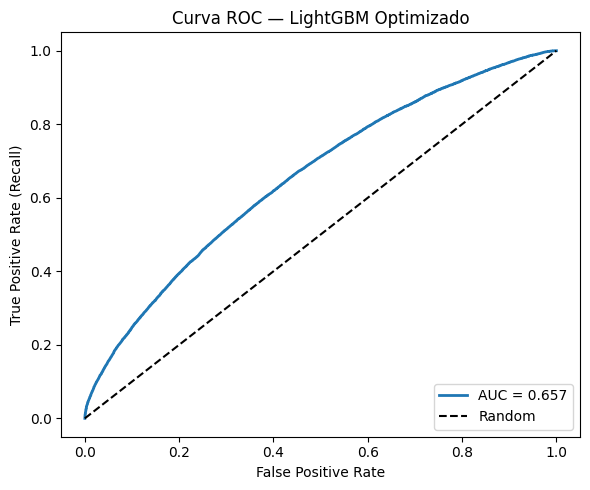

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_roc_curve(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/roc_best_model.png"
)
plt.tight_layout()
plt.show()

## 3. Curva Precision-Recall

La curva Precision-Recall complementa la ROC cuando las clases están desbalanceadas. Muestra el trade-off entre detectar bien los reingresos (recall) y que las alertas sean fiables (precision).

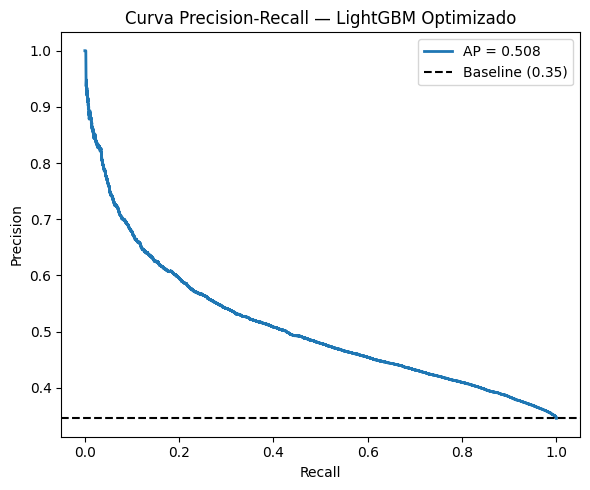

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_precision_recall_curve(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/pr_curve_best_model.png"
)
plt.tight_layout()
plt.show()

## 4. Matriz de confusión y reporte de clasificación

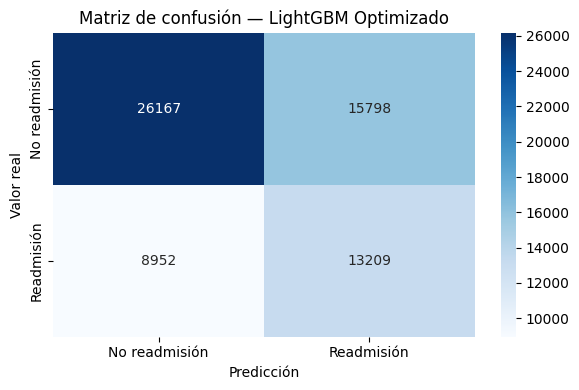

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_confusion_matrix(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/confusion_matrix_best_model.png"
)
plt.tight_layout()
plt.show()

In [9]:
get_classification_report(best_model, X_test, y_test)

,precision,recall,f1-score,support
No readmisión,0.745,0.624,0.679,41965.000
Readmisión,0.455,0.596,0.516,22161.000
accuracy,0.614,0.614,0.614,0.614
macro avg,0.600,0.610,0.598,64126.000
weighted avg,0.645,0.614,0.623,64126.000


## 5. Importancia de variables

Aquí se ve qué variables son las más relevantes para el modelo. Ayuda a entender qué está aprendiendo y aporta algo de interpretabilidad.

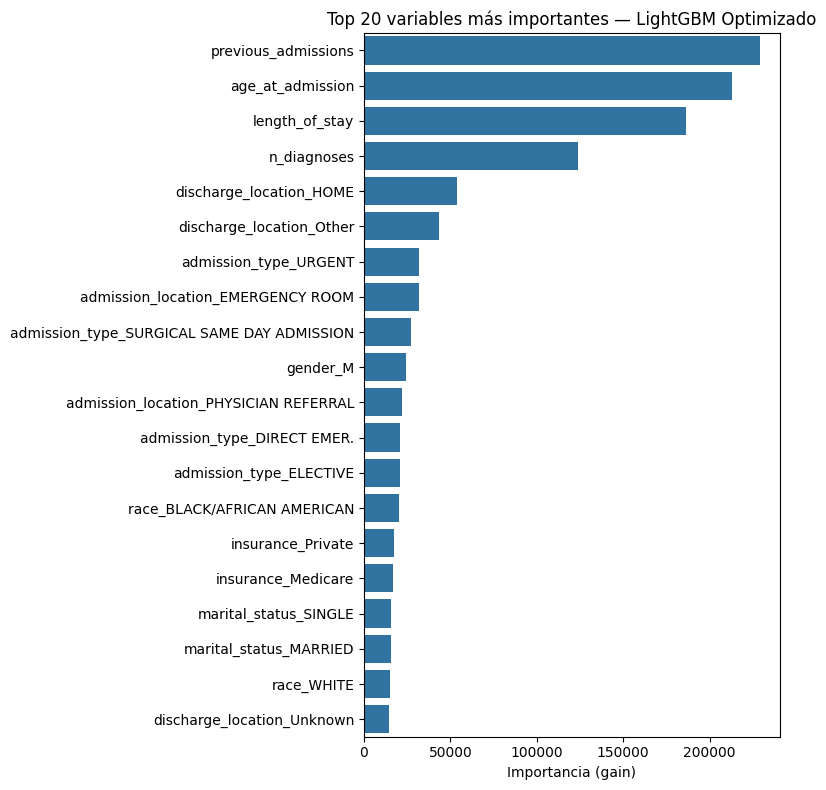

,feature,importance
2,previous_admissions,229242.920429
3,age_at_admission,213073.308481
0,length_of_stay,186134.693279
1,n_diagnoses,123671.519780
48,discharge_location_HOME,54013.276862
50,discharge_location_Other,43557.311626
37,admission_type_URGENT,31974.565609
39,admission_location_EMERGENCY ROOM,31931.435657
36,admission_type_SURGICAL SAME DAY ADMISSION,27143.492937
4,gender_M,24457.675219


In [10]:
importance_df = plot_feature_importance(
    best_model,
    feature_names=X_train.columns.tolist(),
    model_name=best_model_name,
    top_n=20,
    save_path="../results/feature_importance_best_model.png"
)
importance_df

## 6. Análisis de umbral de decisión

El umbral por defecto (0.5) no siempre es el mejor en contexto clínico. Si lo que se quiere es detectar el máximo de pacientes en riesgo, puede tener sentido bajarlo aunque eso suponga más falsos positivos.

El umbral óptimo se selecciona sobre **validación** y se evalúa en **test** para evitar sesgo de selección.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# primero buscamos el umbral óptimo en validación
print("=== Selección de umbral (conjunto de validación) ===")
threshold_df_val = threshold_analysis(best_model, X_val, y_val)
optimal_threshold = threshold_df_val["F1-score"].idxmax()

# lo evaluamos en test
print(f"\n=== Evaluación del umbral óptimo ({optimal_threshold}) sobre test set ===")
y_prob_test = best_model.predict_proba(X_test)[:, 1]
y_pred_optimal = (y_prob_test >= optimal_threshold).astype(int)

results_threshold = {
    "Umbral":     optimal_threshold,
    "Precision":  round(precision_score(y_test, y_pred_optimal, zero_division=0), 4),
    "Recall":     round(recall_score(y_test, y_pred_optimal, zero_division=0), 4),
    "F1-score":   round(f1_score(y_test, y_pred_optimal, zero_division=0), 4),
}

# comparamos con el umbral por defecto 0.5
y_pred_05 = (y_prob_test >= 0.5).astype(int)
results_default = {
    "Umbral":     0.5,
    "Precision":  round(precision_score(y_test, y_pred_05, zero_division=0), 4),
    "Recall":     round(recall_score(y_test, y_pred_05, zero_division=0), 4),
    "F1-score":   round(f1_score(y_test, y_pred_05, zero_division=0), 4),
}

comparison = pd.DataFrame([results_default, results_threshold]).set_index("Umbral")
print("\nComparación umbral 0.5 vs umbral óptimo (test set):")
print(comparison.to_string())
comparison

## 7. Calibración, Brier Score y ECE

Una cosa es que el modelo discrimine bien, y otra que las probabilidades que da sean realistas. Si predice 70% de riesgo, lo ideal es que la tasa real sea más o menos esa.

Para comprobarlo uso tres cosas: la curva de calibración (¿sobre o subestima el riesgo?), el Brier Score (error cuadrático entre probabilidades y etiquetas) y el ECE (cuánto se desvia la calibración del ideal — cuanto más cerca de 0 mejor).

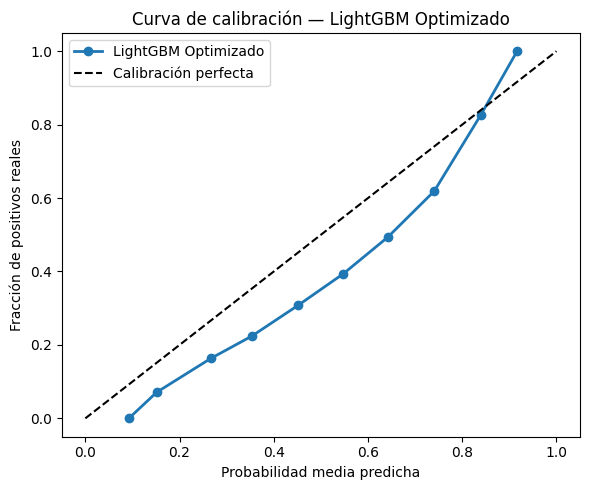


Brier Score:  0.2289
Baseline:     0.2262  (prediciendo siempre la prevalencia)
Mejora:       -0.0028


0.22890750664513818

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_calibration_curve(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/calibration_best_model.png"
)
plt.tight_layout()
plt.show()

print()
brier_score(best_model, X_test, y_test)

In [13]:
expected_calibration_error(best_model, X_test, y_test, n_bins=10)

ECE (Expected Calibration Error): 0.1381
ECE baseline (prevalencia fija):  0.0993
Número de bins:                   10


0.1381482855414491

### 7.2 Postcalibración isotónica

Visto que el modelo sobreestima el riesgo (ECE > baseline), pruebo a corregirlo con **regresión isotónica**. Se ajusta sobre validación y se evalúa en test para ver si las probabilidades mejoran.

In [ ]:
import numpy as np
from sklearn.isotonic import IsotonicRegression

# ajustamos la calibración isotónica sobre validación, nunca sobre test
y_val_proba = best_model.predict_proba(X_val)[:, 1]
ir = IsotonicRegression(out_of_bounds="clip")
ir.fit(y_val_proba, y_val)

class _CalibratedWrapper:
    """Wrapper para aplicar calibración isotónica al modelo."""
    def __init__(self, base_model, ir):
        self.base_model = base_model
        self.ir = ir
    def predict_proba(self, X):
        raw = self.base_model.predict_proba(X)[:, 1]
        cal = self.ir.predict(raw)
        return np.column_stack([1 - cal, cal])

calibrated_model = _CalibratedWrapper(best_model, ir)

# comparamos las curvas antes y después de calibrar
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_calibration_curve(
    best_model, X_test, y_test,
    model_name=f"{best_model_name} (sin calibrar)",
    ax=axes[0],
)
axes[0].set_title(f"Sin calibrar — {best_model_name}")

plot_calibration_curve(
    calibrated_model, X_test, y_test,
    model_name=f"{best_model_name} (isotónica)",
    ax=axes[1],
    save_path="../results/calibration_isotonic.png",
)
axes[1].set_title(f"Calibración isotónica — {best_model_name}")

plt.suptitle("Comparación de calibración antes y después de postcalibración", y=1.01)
plt.tight_layout()
plt.savefig("../results/calibration_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# métricas comparativas en test
print("=== Métricas de calibración en test set ===\n")
print("Modelo sin calibrar:")
bs_base  = brier_score(best_model, X_test, y_test)
ece_base = expected_calibration_error(best_model, X_test, y_test, n_bins=10)

print("\nModelo con calibración isotónica:")
bs_cal  = brier_score(calibrated_model, X_test, y_test)
ece_cal = expected_calibration_error(calibrated_model, X_test, y_test, n_bins=10)

print(f"\nResumen:")
print(f"  Brier Score:  {bs_base:.4f} → {bs_cal:.4f}  (delta {bs_cal - bs_base:+.4f})")
print(f"  ECE:          {ece_base:.4f} → {ece_cal:.4f}  (delta {ece_cal - ece_base:+.4f})")

# guardamos el modelo calibrado por si hace falta después
import joblib
joblib.dump(calibrated_model, "../models/lightgbm_calibrated.pkl")
print("Modelo calibrado guardado en models/lightgbm_calibrated.pkl")

## 8. Decision Curve Analysis (DCA)

La DCA compara el modelo con dos alternativas simples: tratar a todos los pacientes o no tratar a nadie. Si la curva del modelo queda por encima de esas dos líneas en algún rango de umbrales, significa que usarlo tiene beneficio real en ese contexto.

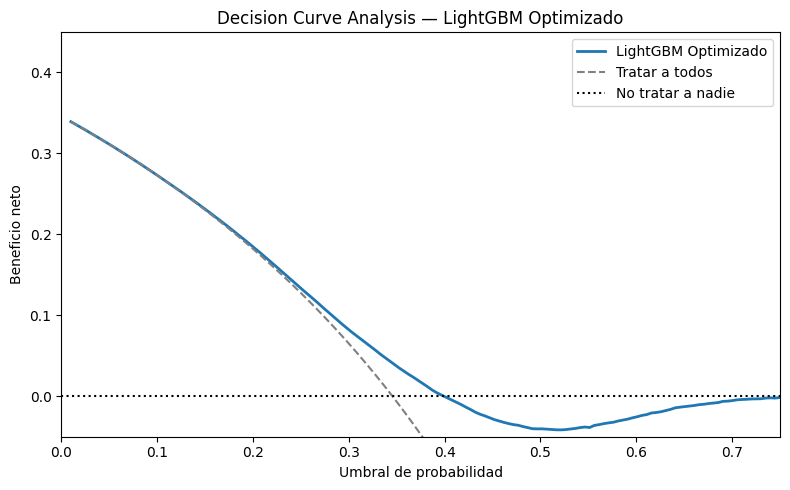

,threshold,net_benefit_model,net_benefit_all
0,0.010000,0.338975,0.338975
1,0.014966,0.335642,0.335642
2,0.019933,0.332276,0.332276
3,0.024899,0.328875,0.328875
4,0.029866,0.325439,0.325439
5,0.034832,0.321968,0.321968
6,0.039799,0.318461,0.318461
7,0.044765,0.314917,0.314917
8,0.049732,0.311337,0.311337
9,0.054698,0.307719,0.307719


In [15]:
dca_df = plot_dca(
    best_model, X_test, y_test,
    model_name=best_model_name,
    save_path="../results/dca_best_model.png"
)
dca_df.head(10)

## 9. Interpretabilidad SHAP

SHAP explica cuánto contribuye cada variable a cada predicción concreta. A diferencia de la importancia por ganancia de la sección anterior, tiene en cuenta cómo interactúan las variables entre sí.

Los valores tienen signo: positivo empuja hacia predecir reingreso, negativo hacia no reingreso.

Se usa una muestra de 2.000 registros para que el cálculo no tarde demasiado.

c:\Users\skipe\miniforge3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


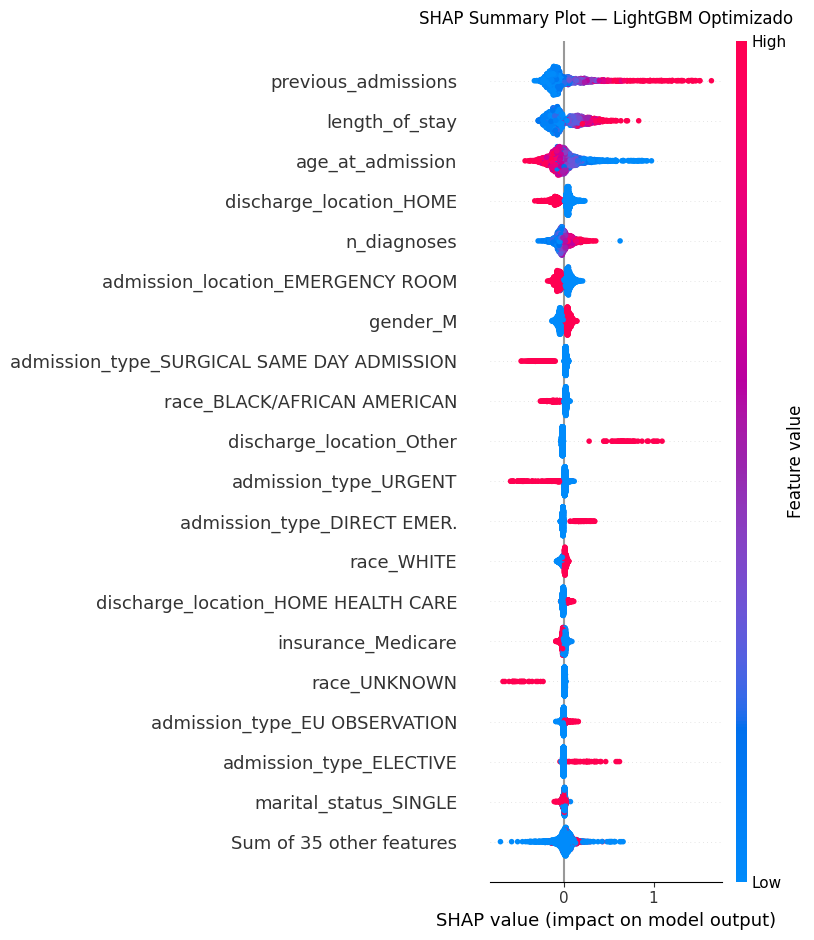

,feature,mean_abs_shap
0,previous_admissions,0.170600
1,length_of_stay,0.148140
2,age_at_admission,0.124556
3,discharge_location_HOME,0.073422
4,n_diagnoses,0.063596
5,admission_location_EMERGENCY ROOM,0.059322
6,gender_M,0.048548
7,admission_type_SURGICAL SAME DAY ADMISSION,0.041903
8,race_BLACK/AFRICAN AMERICAN,0.036155
9,discharge_location_Other,0.033292


In [16]:
X_sample = X_test.sample(n=2000, random_state=42)

shap_df = plot_shap_summary(
    best_model, X_sample,
    model_name=best_model_name,
    max_display=20,
    save_path="../results/shap_summary_best_model.png"
)
shap_df

### 9.2 Explicación local: waterfall plots

El beeswarm de antes muestra el modelo de forma global. Para ver casos concretos, miro los *waterfall plots* del paciente con mayor y menor riesgo predicho. Cada barra indica cuánto empuja cada variable en esa predicción.

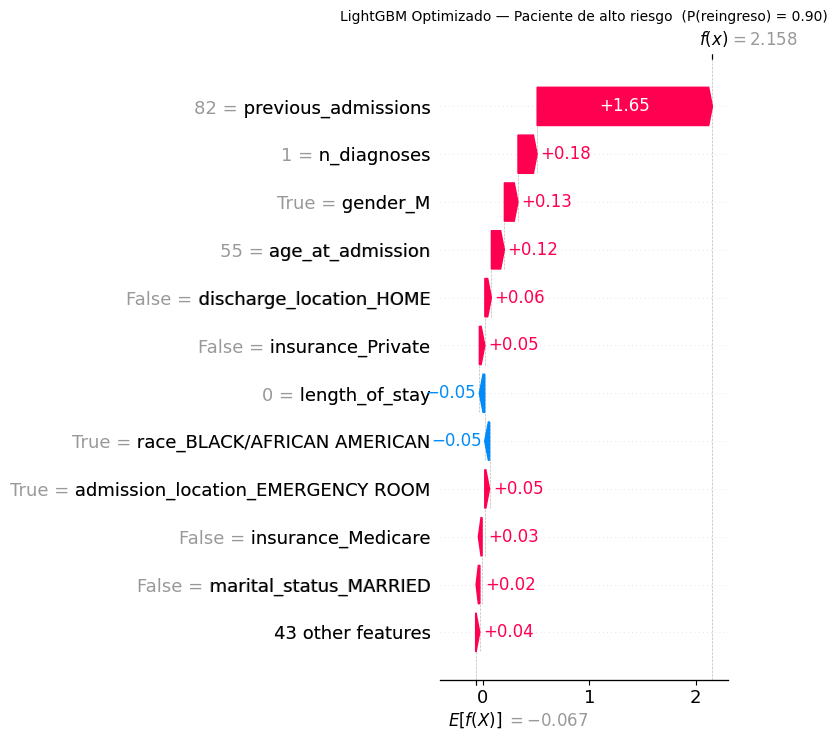

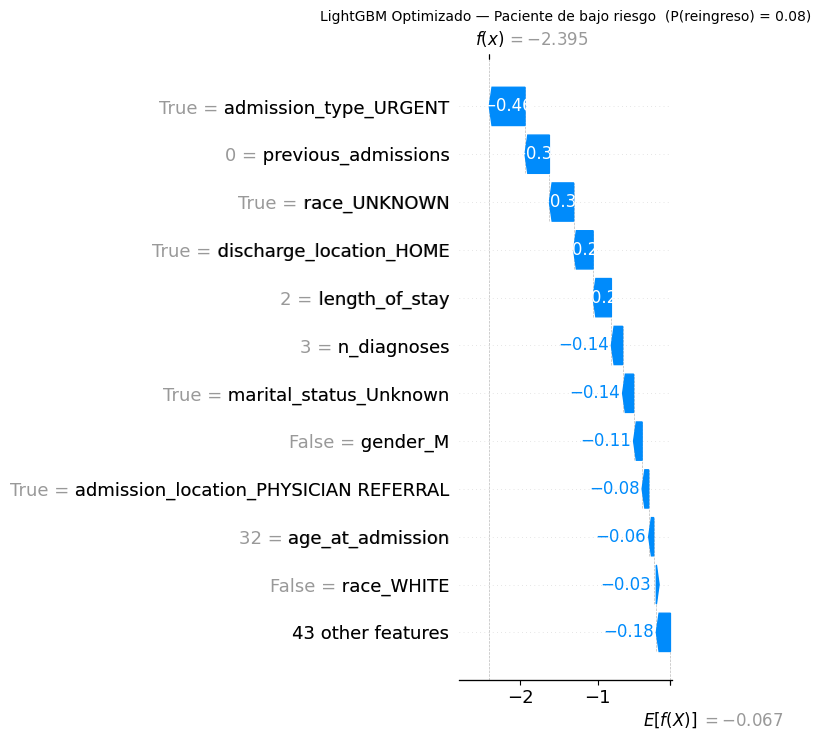

{'idx_high': 1856, 'idx_low': 1891, 'prob_high': 0.896, 'prob_low': 0.084}


In [17]:
waterfall_info = plot_shap_waterfall(
    best_model, X_sample,
    model_name=best_model_name,
    max_display=12,
    save_path_high="../results/shap_waterfall_high_risk.png",
    save_path_low="../results/shap_waterfall_low_risk.png",
)
print(waterfall_info)


## 10. Conclusiones

Un resumen de lo que se ha visto para el LightGBM optimizado:

- La **curva ROC** y la **Precision-Recall** confirman un AUC ~0.66, que está en línea con lo que sale en la literatura para datos administrativos.
- La **importancia de variables** y los **valores SHAP** dan una idea de qué factores pesan más.
- El **análisis de umbral** permite ajustar el punto de corte: bajarlo detecta más reingresos pero genera más falsos positivos.
- La **calibración** (Brier Score + ECE) indica que el modelo tiende a sobreestimar el riesgo, así que las probabilidades hay que interpretarlas con cautela; en producción convendría calibrar antes.
- La **DCA** muestra en qué rango de umbrales el modelo tiene beneficio real frente a las opciones triviales.

**Nota:** los datos se dividen por paciente con `GroupShuffleSplit`. Al comparar con la división aleatoria las métricas varían menos de 0.002 AUC, lo que confirma que no hay leakage entre admisiones del mismo paciente.